# How natural gas is sold to Europe

[![Open in Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/EvenSol/NeqSim-Colab/blob/master/notebooks/gasvaluechain/european_gas_sales_market_foundation.ipynb)

**Consumer, shipper/transporter, and producer perspectives with NeqSim**

This notebook follows one gas-day transaction from a Norwegian producer to a European
industrial consumer. It separates physical flow, commodity title, capacity rights,
nominations, balancing, allocation, and cash settlement. A small market model then connects
NeqSim gas quality and compression to dispatch, consumer cost, transport utilisation, and
producer netback.

All prices, tariffs, capacities, contracts, and profiles are synthetic teaching assumptions.
They are not current quotes, legal advice, a tariff filing, or a trading recommendation.

## Learning outcomes

After running the notebook, you should be able to:

1. distinguish a gas molecule from commodity title, transport capacity, and money;
2. explain what consumers, shippers, TSOs, storage operators, traders, and producers do;
3. translate standard volume to contract energy with NeqSim and ISO 6976;
4. formulate source dispatch and interpret its marginal delivered price;
5. calculate consumer cost, imbalance, transporter utilisation, and producer netback; and
6. identify Python tools and public data sources for a larger European market model.

## 1. Four ledgers describe the same gas day

| Ledger | What moves | Main records | Typical decision owner |
|---|---|---|---|
| Physical | molecules and energy | flow, pressure, quality, allocation | producer and system operator |
| Commercial | title to gas | bilateral, hub, spot, forward, retail | producer, trader, supplier, consumer |
| Capacity | right to infrastructure | entry/exit booking, nomination, renomination | shipper or network user |
| Financial | money and collateral | invoices, margin, imbalance, tax, credit | all commercial parties |

A producer can sell title at a hub without the buyer operating a pipeline. A TSO can move
gas without buying the commodity. A consumer can fix a price financially while receiving
physical gas from a changing portfolio. Confusing these ledgers causes double counting.

### Simplified lifecycle

1. Contract supply, hedge price, and secure capacity months or years ahead.
2. Nominate entry and exit quantities for the next gas day.
3. Renominate or trade within day as demand forecasts change.
4. Operate the network; meter volume and gas quality.
5. Allocate measured quantities to shippers and consumers.
6. Settle commodity, capacity, balancing, network, tax, and credit invoices.

### European and Norwegian institutional anchors

- The [European Commission gas network-code overview](https://energy.ec.europa.eu/topics/markets-and-consumers/wholesale-energy-market/gas-network-codes_en)
  covers capacity auctions, balancing, interoperability, and tariff structures.
- [ENTSOG's Transparency Platform](https://transparency.entsog.eu/) publishes capacities,
  nominations, allocations, and physical flows for European transmission systems.
- [Gassco](https://gassco.eu/en/shippers/capacity-booking-and-reporting/) operates the
  integrated Norwegian gas transport system. Authorised shippers book capacity, compare
  bookings and nominations, and pay regulated tariffs.
- [ACER](https://www.acer.europa.eu/monitoring/MMR) monitors wholesale markets, hub prices,
  trading, capacity use, infrastructure, supply, and demand.
- [Eurostat](https://ec.europa.eu/eurostat/web/energy/database) publishes harmonised demand,
  trade, and consumer-price statistics. Exchange hub prices normally need a data licence.

Gassco is a neutral system operator and capacity manager, not the commodity seller. The
producer or marketing entity sells the gas and arranges the required transport rights.

## 2. Reproducible runtime and NeqSim Java `master`

In Colab, the next cell installs the Python bridge, clones `equinor/neqsim` `master`, and
builds its Java JAR. Local validation points to the same source checkout and source-built
JAR. The resolved commit, SHA-256 digest, and Java class location are retained.

In [1]:
import hashlib
import os
import platform
import subprocess
import sys
from pathlib import Path

IN_COLAB = "google.colab" in sys.modules
NEQSIM_SOURCE_REF = os.environ.get("NEQSIM_SOURCE_REF", "master")
os.environ.setdefault("NEQSIM_JVM_AUTOSTART", "false")

if IN_COLAB:
    subprocess.run(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-q",
            "jpype1==1.7.1",
            "numpy",
            "pandas",
            "matplotlib",
            "scipy",
            "networkx",
        ],
        check=True,
    )
    source_root = Path("neqsim-java-master")
    if not source_root.exists():
        subprocess.run(
            [
                "git",
                "clone",
                "--depth",
                "1",
                "--branch",
                NEQSIM_SOURCE_REF,
                "https://github.com/equinor/neqsim.git",
                str(source_root),
            ],
            check=True,
        )
    subprocess.run(
        ["./mvnw", "-q", "-DskipTests", "package"],
        cwd=source_root,
        check=True,
    )
    candidates = sorted((source_root / "target").glob("neqsim-*.jar"))
    candidates = [path for path in candidates if "original" not in path.name]
    if not candidates:
        raise FileNotFoundError("The NeqSim source build produced no runtime JAR.")
    NEQSIM_JAR = max(candidates, key=lambda path: path.stat().st_size).resolve()
else:
    source_root = Path(os.environ.get("NEQSIM_SOURCE_ROOT", "neqsim-java-master"))
    source_jar = os.environ.get("NEQSIM_SOURCE_JAR", "")
    if not source_jar:
        raise RuntimeError("Set NEQSIM_SOURCE_JAR for local clean validation.")
    NEQSIM_JAR = Path(source_jar).resolve()

NEQSIM_COMMIT = subprocess.check_output(
    ["git", "rev-parse", "HEAD"],
    cwd=source_root,
    text=True,
).strip()
NEQSIM_JAR_SHA256 = hashlib.sha256(NEQSIM_JAR.read_bytes()).hexdigest()
dependency_text = os.environ.get("NEQSIM_DEPENDENCY_JAR", "")
NEQSIM_DEPENDENCY_JARS = [
    Path(item).resolve()
    for item in dependency_text.split(os.pathsep)
    if item
]

print(f"NeqSim source ref: {NEQSIM_SOURCE_REF}")
print(f"NeqSim source commit: {NEQSIM_COMMIT}")
print(f"NeqSim source-built JAR: {NEQSIM_JAR}")
print(f"NeqSim JAR SHA-256: {NEQSIM_JAR_SHA256}")
print(f"Python: {platform.python_version()}")

NeqSim source ref: master
NeqSim source commit: 7ae08253b45180045a99a700314f23c9a7001b3c
NeqSim source-built JAR: /workspace/scratch/677f236dc7cc/gas-market-work/neqsim-java-master/target/neqsim-current-master.jar
NeqSim JAR SHA-256: 03c88c492eca2c989aed2a8495248d68f85e29c260609d7386f599c903bd96d7
Python: 3.12.13


In [2]:
import json
import math
from importlib import metadata

import jpype
import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import scipy
from IPython.display import display
from jpype import JClass
from matplotlib.patches import Patch
from scipy.optimize import linprog

plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams.update({"figure.dpi": 120, "axes.titleweight": "bold"})
pd.set_option("display.max_columns", 30)

class_path = [str(NEQSIM_JAR)]
class_path.extend(str(path) for path in NEQSIM_DEPENDENCY_JARS)
if not jpype.isJVMStarted():
    # Direct JVM startup is the validated equivalent of jpype.addClassPath.
    jpype.startJVM(classpath=class_path)

SystemSrkEos = JClass("neqsim.thermo.system.SystemSrkEos")
StandardISO6976 = JClass(
    "neqsim.standards.gasquality.Standard_ISO6976_2016"
)
Stream = JClass("neqsim.process.equipment.stream.Stream")
Compressor = JClass("neqsim.process.equipment.compressor.Compressor")
ProcessSystem = JClass("neqsim.process.processmodel.ProcessSystem")
class_source = str(
    SystemSrkEos.class_.getProtectionDomain().getCodeSource().getLocation()
)
print(f"Loaded NeqSim class code source: {class_source}")
assert str(NEQSIM_JAR) in class_source

Loaded NeqSim class code source: file:/workspace/scratch/677f236dc7cc/gas-market-work/neqsim-java-master/target/neqsim-current-master.jar


## 3. Python tools for European gas-market analysis

No single library covers contracts, regulated transport, physical quality, market prices,
and optimisation. Separate acquisition, modelling, thermodynamics, and reporting. Review
API limits, licences, and market-data entitlements before redistributing data.

In [3]:
tool_rows = [
    ["Transmission", "ENTSOG TP API", "requests, entsog-py, eurogastp",
     "capacity, nomination, allocation, flow", "public; rate limits"],
    ["Storage and LNG", "GIE AGSI/ALSI", "requests or eurogastp",
     "inventory, injection, withdrawal, LNG send-out", "API key and terms"],
    ["Demand and prices", "Eurostat API", "eurostat, pandasdmx, requests",
     "consumption, imports, industrial prices", "public API"],
    ["Market monitoring", "ACER reports", "pandas with downloaded tables",
     "liquidity, spreads, supply, infrastructure", "reports public; quotes may not be"],
    ["Norwegian transport", "Gassco Booking", "authorised shipper exports",
     "booking, nomination, capacity, invoices", "authorised shippers"],
    ["Physical quality", "NeqSim Java master", "JPype",
     "GCV, Wobbe, density, compression, phase behaviour", "open source"],
    ["Networks", "NetworkX", "networkx", "topology and visual checks", "open source"],
    ["Optimisation", "SciPy / Pyomo / CVXPY", "linprog or algebraic models",
     "dispatch, storage, capacity, dual prices", "solver licences vary"],
]
tool_table = pd.DataFrame(
    tool_rows,
    columns=["Layer", "Source or tool", "Python route", "Variables", "Access"],
)
display(tool_table)

,Layer,Source or tool,Python route,Variables,Access
0,Transmission,ENTSOG TP API,"requests, entsog-py, eurogastp","capacity, nomination, allocation, flow",public; rate limits
1,Storage and LNG,GIE AGSI/ALSI,requests or eurogastp,"inventory, injection, withdrawal, LNG send-out",API key and terms
2,Demand and prices,Eurostat API,"eurostat, pandasdmx, requests","consumption, imports, industrial prices",public API
3,Market monitoring,ACER reports,pandas with downloaded tables,"liquidity, spreads, supply, infrastructure",reports public; quotes may not be
4,Norwegian transport,Gassco Booking,authorised shipper exports,"booking, nomination, capacity, invoices",authorised shippers
5,Physical quality,NeqSim Java master,JPype,"GCV, Wobbe, density, compression, phase behaviour",open source
6,Networks,NetworkX,networkx,topology and visual checks,open source
7,Optimisation,SciPy / Pyomo / CVXPY,linprog or algebraic models,"dispatch, storage, capacity, dual prices",solver licences vary


### Reproducible data policy

The case runs from a complete synthetic snapshot. Live queries are disabled because APIs
change, GIE needs a key, and exchange prices may be licensed. Production acquisition code
should write a dated raw snapshot and metadata before cleaning; analysis should read that
snapshot, never an unversioned live response.

In [4]:
USE_LIVE_DATA = False
endpoint_catalog = pd.DataFrame(
    [
        ["ENTSOG operational data",
         "https://transparency.entsog.eu/api/v1/operationaldatas", "none"],
        ["GIE AGSI storage", "https://agsi.gie.eu/api", "API key"],
        ["Eurostat industrial gas prices",
         "https://ec.europa.eu/eurostat/api/dissemination/statistics/1.0/data/nrg_pc_203",
         "none"],
    ],
    columns=["Dataset", "Official URL", "Authentication"],
)
display(endpoint_catalog)
print("Base-case provenance: synthetic teaching data; no live endpoint was called.")
assert not USE_LIVE_DATA

Base-case provenance: synthetic teaching data; no live endpoint was called.


,Dataset,Official URL,Authentication
0,ENTSOG operational data,https://transparency.entsog.eu/api/v1/operatio...,none
1,GIE AGSI storage,https://agsi.gie.eu/api,API key
2,Eurostat industrial gas prices,https://ec.europa.eu/eurostat/api/disseminatio...,none


## 4. Worked case: Norwegian gas to an industrial consumer

The consumer needs 150,000 MWh during one gas day. Norwegian pipeline gas, storage,
and LNG can serve it. Title is priced in energy while meters observe volume and quality:

$$E_{\mathrm{MWh}}=V_{\mathrm{Sm^3}}\frac{H_{\mathrm{s,MJ/Sm^3}}}{3600}$$

$E$ is contract energy, $V$ is standard volume, and $H_{\mathrm{s}}$ is gross calorific
value. The example uses 15 °C and 1.01325 bara, with combustion reference 25 °C.
The actual contract defines the applicable reference states and averaging rules.

In [5]:
DAILY_DEMAND_MWH = 150_000.0
STANDARD_TEMPERATURE_C = 15.0
STANDARD_PRESSURE_BARA = 1.01325
COMBUSTION_REFERENCE_C = 25.0

BASE_GAS = {
    "methane": 0.900,
    "ethane": 0.050,
    "propane": 0.015,
    "i-butane": 0.003,
    "n-butane": 0.004,
    "nitrogen": 0.020,
    "CO2": 0.008,
}
CO2_RICH_GAS = dict(BASE_GAS)
CO2_RICH_GAS["methane"] -= 0.012
CO2_RICH_GAS["CO2"] += 0.012

composition_table = pd.DataFrame(
    {
        "Base gas [mol%]": pd.Series(BASE_GAS) * 100.0,
        "CO2-rich gas [mol%]": pd.Series(CO2_RICH_GAS) * 100.0,
    }
)
display(composition_table.round(3))
assert math.isclose(sum(BASE_GAS.values()), 1.0, abs_tol=1.0e-12)
assert math.isclose(sum(CO2_RICH_GAS.values()), 1.0, abs_tol=1.0e-12)

,Base gas [mol%],CO2-rich gas [mol%]
methane,90.0,88.8
ethane,5.0,5.0
propane,1.5,1.5
i-butane,0.3,0.3
n-butane,0.4,0.4
nitrogen,2.0,2.0
CO2,0.8,2.0


### NeqSim gas quality: why energy, not volume, is sold

NeqSim applies SRK with the classic mixing rule. ISO 6976:2016 calculates gross and
net calorific value, Wobbe index, and relative density. This is a dry synthetic gas;
water, sulfur, dew point, and every contractual quality limit need separate checks.

In [6]:
def build_srk_gas(composition, temperature_c, pressure_bara):
    gas = SystemSrkEos(temperature_c + 273.15, pressure_bara)
    for component_name, mole_fraction in composition.items():
        gas.addComponent(component_name, mole_fraction)
    gas.setMixingRule("classic")
    gas.setMultiPhaseCheck(False)
    gas.init(0)
    gas.init(1)
    return gas


def iso6976_quality(composition):
    gas = build_srk_gas(
        composition,
        STANDARD_TEMPERATURE_C,
        STANDARD_PRESSURE_BARA,
    )
    standard = StandardISO6976(
        gas,
        STANDARD_TEMPERATURE_C,
        COMBUSTION_REFERENCE_C,
        "volume",
    )
    standard.setReferenceState("real")
    standard.calculate()
    return {
        "Gross CV [MJ/Sm3]": (
            standard.getValue("SuperiorCalorificValue") / 1000.0
        ),
        "Net CV [MJ/Sm3]": (
            standard.getValue("InferiorCalorificValue") / 1000.0
        ),
        "Wobbe [MJ/Sm3]": (
            standard.getValue("SuperiorWobbeIndex") / 1000.0
        ),
        "Relative density [-]": standard.getValue("RelativeDensity"),
        "Density [kg/Sm3]": gas.getDensity("kg/m3"),
    }


base_quality = iso6976_quality(BASE_GAS)
rich_quality = iso6976_quality(CO2_RICH_GAS)
quality_table = pd.DataFrame(
    [base_quality, rich_quality],
    index=["Base gas", "CO2-rich gas"],
)
display(quality_table.round(5))

,Gross CV [MJ/Sm3],Net CV [MJ/Sm3],Wobbe [MJ/Sm3],Relative density [-],Density [kg/Sm3]
Base gas,39.55165,35.73765,50.23156,0.61998,0.0
CO2-rich gas,39.10001,35.33063,49.19856,0.63161,0.0


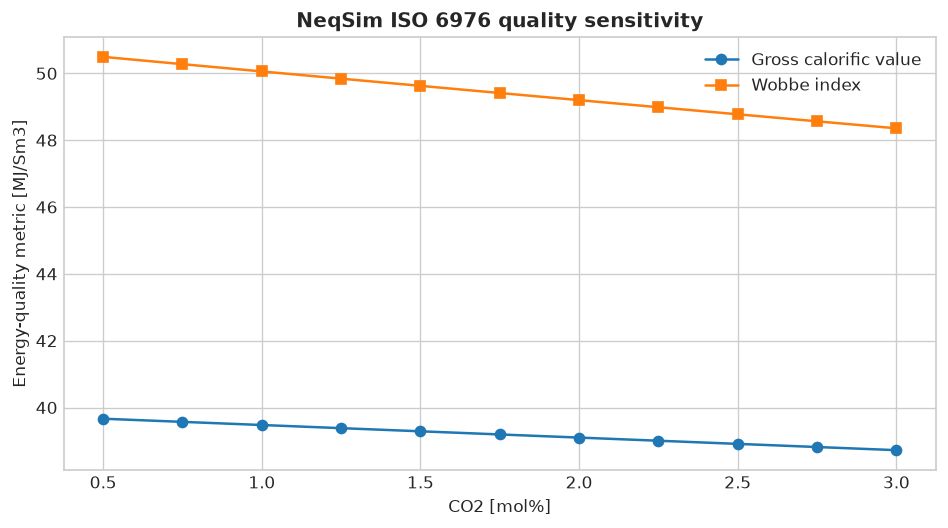

In [7]:
quality_rows = []
for co2_mol_percent in np.linspace(0.5, 3.0, 11):
    composition = dict(BASE_GAS)
    delta_fraction = co2_mol_percent / 100.0 - BASE_GAS["CO2"]
    composition["CO2"] = co2_mol_percent / 100.0
    composition["methane"] -= delta_fraction
    quality = iso6976_quality(composition)
    quality_rows.append(
        {
            "CO2 [mol%]": co2_mol_percent,
            "Gross CV [MJ/Sm3]": quality["Gross CV [MJ/Sm3]"],
            "Wobbe [MJ/Sm3]": quality["Wobbe [MJ/Sm3]"],
        }
    )

quality_sensitivity = pd.DataFrame(quality_rows)
figure, axis = plt.subplots(figsize=(8, 4.5))
axis.plot(
    quality_sensitivity["CO2 [mol%]"],
    quality_sensitivity["Gross CV [MJ/Sm3]"],
    marker="o",
    label="Gross calorific value",
)
axis.plot(
    quality_sensitivity["CO2 [mol%]"],
    quality_sensitivity["Wobbe [MJ/Sm3]"],
    marker="s",
    label="Wobbe index",
)
axis.set_xlabel("CO2 [mol%]")
axis.set_ylabel("Energy-quality metric [MJ/Sm3]")
axis.set_title("NeqSim ISO 6976 quality sensitivity")
axis.legend()
figure.tight_layout()
plt.show()

### Metered volume and energy allocation

A fixed MWh delivery requires more standard volume when inert CO2 replaces methane.
Real allocation also combines calibrated meters, chromatographs, averaging rules,
linepack, and the balancing-zone methodology.

In [8]:
def required_volume_million_sm3(energy_mwh, gross_cv_mj_sm3):
    return energy_mwh * 3600.0 / gross_cv_mj_sm3 / 1.0e6


base_volume_msm3 = required_volume_million_sm3(
    DAILY_DEMAND_MWH,
    base_quality["Gross CV [MJ/Sm3]"],
)
rich_volume_msm3 = required_volume_million_sm3(
    DAILY_DEMAND_MWH,
    rich_quality["Gross CV [MJ/Sm3]"],
)
settlement_table = pd.DataFrame(
    [
        ["Base gas", base_quality["Gross CV [MJ/Sm3]"],
         DAILY_DEMAND_MWH, base_volume_msm3],
        ["CO2-rich gas", rich_quality["Gross CV [MJ/Sm3]"],
         DAILY_DEMAND_MWH, rich_volume_msm3],
    ],
    columns=[
        "Gas",
        "Gross CV [MJ/Sm3]",
        "Delivered energy [MWh]",
        "Required volume [million Sm3]",
    ],
)
display(settlement_table.round(4))
print(
    "Extra standard volume for equal energy: "
    f"{rich_volume_msm3 - base_volume_msm3:.4f} million Sm3/day"
)

Extra standard volume for equal energy: 0.1577 million Sm3/day


,Gas,Gross CV [MJ/Sm3],Delivered energy [MWh],Required volume [million Sm3]
0,Base gas,39.5517,150000.0,13.6530
1,CO2-rich gas,39.1000,150000.0,13.8107


### NeqSim export compression and the producer cost stack

The calculation preserves named NeqSim streams and a `ProcessSystem`, so a detailed
offshore or onshore model can replace it. The screen compresses 10 million Sm3/day
from 50 to 120 bara at 78% polytropic efficiency. It is not a specific Gassco station.

In [9]:
compression_gas = build_srk_gas(BASE_GAS, 15.0, 50.0)
export_feed = Stream("Norwegian export gas", compression_gas)
export_feed.setFlowRate(10.0, "MSm3/day")
export_feed.setPressure(50.0, "bara")

export_compressor = Compressor("Illustrative export compressor", export_feed)
export_compressor.setOutletPressure(120.0, "bara")
export_compressor.setUsePolytropicCalc(True)
export_compressor.setPolytropicEfficiency(0.78)
compression_process = ProcessSystem()
compression_process.add(export_feed)
compression_process.add(export_compressor)
compression_process.run()

compressor_power_mw = export_compressor.getPower("kW") / 1000.0
gas_energy_mwh_day = (
    10.0e6 * base_quality["Gross CV [MJ/Sm3]"] / 3600.0
)
electricity_mwh_day = compressor_power_mw * 24.0
specific_power_kwh_mwh = electricity_mwh_day * 1000.0 / gas_energy_mwh_day
ELECTRICITY_PRICE_EUR_MWH = 70.0
compression_cost_eur_mwh = (
    electricity_mwh_day * ELECTRICITY_PRICE_EUR_MWH / gas_energy_mwh_day
)
compression_summary = pd.Series(
    {
        "Feed rate [million Sm3/day]": 10.0,
        "Suction pressure [bara]": export_feed.getPressure("bara"),
        "Discharge pressure [bara]": (
            export_compressor.getOutletStream().getPressure("bara")
        ),
        "Power [MW]": compressor_power_mw,
        "Specific electricity [kWh/MWh gas]": specific_power_kwh_mwh,
        "Electricity cost [EUR/MWh gas]": compression_cost_eur_mwh,
    },
    name="NeqSim compression screen",
)
display(compression_summary.to_frame().round(4))

,NeqSim compression screen
Feed rate [million Sm3/day],10.0000
Suction pressure [bara],50.0000
Discharge pressure [bara],120.0000
Power [MW],13.6963
Specific electricity [kWh/MWh gas],2.9919
Electricity cost [EUR/MWh gas],0.2094


## 5. Physical network and commercial delivery routes

Norwegian gas and LNG enter around TTF, storage enters near the German THE zone, and
all reach one consumer. Title can change at TTF or THE although physical molecules are
commingled and cannot be traced contract by contract.

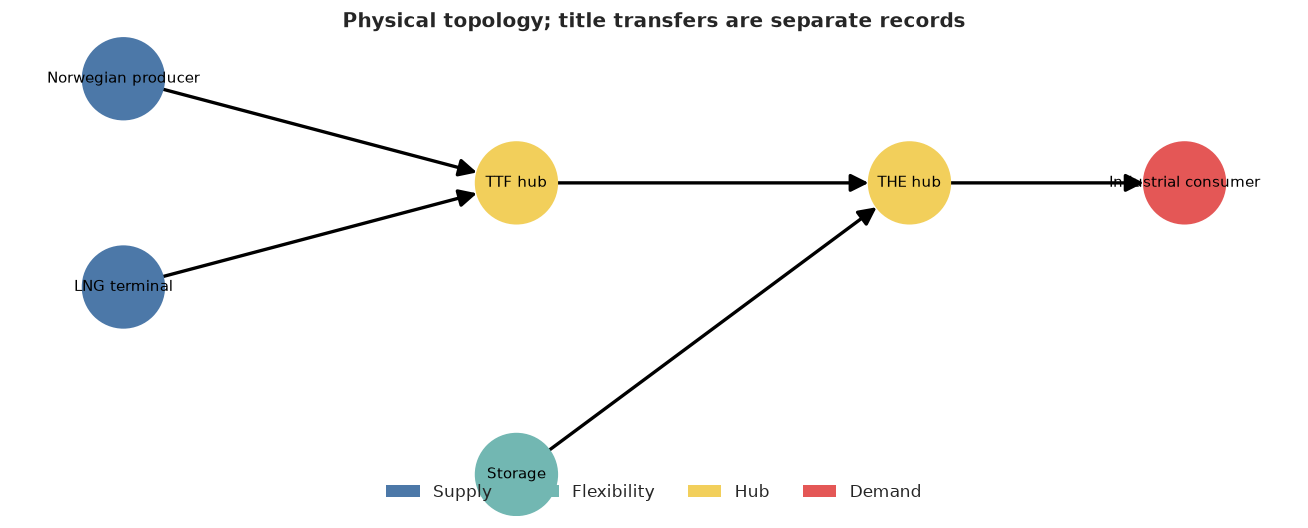

In [10]:
market_graph = nx.DiGraph()
node_types = {
    "Norwegian producer": "Supply",
    "LNG terminal": "Supply",
    "Storage": "Flexibility",
    "TTF hub": "Hub",
    "THE hub": "Hub",
    "Industrial consumer": "Demand",
}
market_graph.add_nodes_from(node_types)
market_graph.add_edges_from(
    [
        ("Norwegian producer", "TTF hub"),
        ("LNG terminal", "TTF hub"),
        ("TTF hub", "THE hub"),
        ("Storage", "THE hub"),
        ("THE hub", "Industrial consumer"),
    ]
)
positions = {
    "Norwegian producer": (0.0, 1.2),
    "LNG terminal": (0.0, 0.2),
    "Storage": (2.0, -0.7),
    "TTF hub": (2.0, 0.7),
    "THE hub": (4.0, 0.7),
    "Industrial consumer": (5.4, 0.7),
}
type_colors = {
    "Supply": "#4C78A8",
    "Flexibility": "#72B7B2",
    "Hub": "#F2CF5B",
    "Demand": "#E45756",
}
node_colors = [type_colors[node_types[node]] for node in market_graph.nodes]
figure, axis = plt.subplots(figsize=(11, 4.5))
nx.draw_networkx(
    market_graph,
    pos=positions,
    node_color=node_colors,
    node_size=2400,
    font_size=9,
    arrowsize=22,
    width=2.0,
    ax=axis,
)
legend_handles = [
    Patch(facecolor=color, label=node_type)
    for node_type, color in type_colors.items()
]
axis.legend(handles=legend_handles, loc="lower center", ncol=4)
axis.set_title("Physical topology; title transfers are separate records")
axis.axis("off")
figure.tight_layout()
plt.show()

### Least-cost dispatch and a marginal delivered price

Let $x_s$ be energy from source $s$, $c_s$ its delivered variable cost,
$\bar{x}_s$ capacity, and $D$ demand:

$$\min_x\sum_s c_sx_s$$

subject to $\sum_s x_s=D$, $0\leq x_s\leq\bar{x}_s$, and a shared
TTF-to-THE corridor. The demand dual is the marginal cost of one more MWh in this
linear teaching model. It is not a TTF forecast.

In [11]:
routes = pd.DataFrame(
    {
        "Source": ["Norwegian pipeline", "Storage withdrawal", "LNG"],
        "Supply cost [EUR/MWh]": [25.0, 29.5, 32.0],
        "Transport cost [EUR/MWh]": [3.1, 1.1, 2.7],
        "Capacity [MWh/day]": [90_000.0, 40_000.0, 80_000.0],
        "Uses TTF-THE corridor": [1.0, 0.0, 1.0],
    }
)
routes["Delivered cost [EUR/MWh]"] = (
    routes["Supply cost [EUR/MWh]"]
    + routes["Transport cost [EUR/MWh]"]
)
display(routes.round(2))


def solve_dispatch(demand_mwh, norway_capacity_mwh=90_000.0):
    capacities = routes["Capacity [MWh/day]"].to_numpy().copy()
    capacities[0] = norway_capacity_mwh
    result = linprog(
        c=routes["Delivered cost [EUR/MWh]"].to_numpy(),
        A_ub=[routes["Uses TTF-THE corridor"].to_numpy()],
        b_ub=[130_000.0],
        A_eq=[np.ones(len(routes))],
        b_eq=[demand_mwh],
        bounds=[(0.0, capacity) for capacity in capacities],
        method="highs",
    )
    if not result.success:
        raise RuntimeError(result.message)
    return result


base_dispatch = solve_dispatch(DAILY_DEMAND_MWH)
outage_dispatch = solve_dispatch(
    DAILY_DEMAND_MWH,
    norway_capacity_mwh=45_000.0,
)
dispatch_table = pd.DataFrame(
    {
        "Source": routes["Source"],
        "Base flow [MWh/day]": base_dispatch.x,
        "Norway outage flow [MWh/day]": outage_dispatch.x,
        "Capacity [MWh/day]": routes["Capacity [MWh/day]"],
    }
)
display(dispatch_table.round(1))
print(
    "Base marginal delivered price: "
    f"{base_dispatch.eqlin.marginals[0]:.2f} EUR/MWh"
)
print(f"Base daily system cost: {base_dispatch.fun / 1.0e6:.3f} million EUR")

Base marginal delivered price: 34.70 EUR/MWh
Base daily system cost: 4.447 million EUR


,Source,Supply cost [EUR/MWh],Transport cost [EUR/MWh],Capacity [MWh/day],Uses TTF-THE corridor,Delivered cost [EUR/MWh]
0,Norwegian pipeline,25.0,3.1,90000.0,1.0,28.1
1,Storage withdrawal,29.5,1.1,40000.0,0.0,30.6
2,LNG,32.0,2.7,80000.0,1.0,34.7


,Source,Base flow [MWh/day],Norway outage flow [MWh/day],Capacity [MWh/day]
0,Norwegian pipeline,90000.0,45000.0,90000.0
1,Storage withdrawal,40000.0,40000.0,40000.0
2,LNG,20000.0,65000.0,80000.0


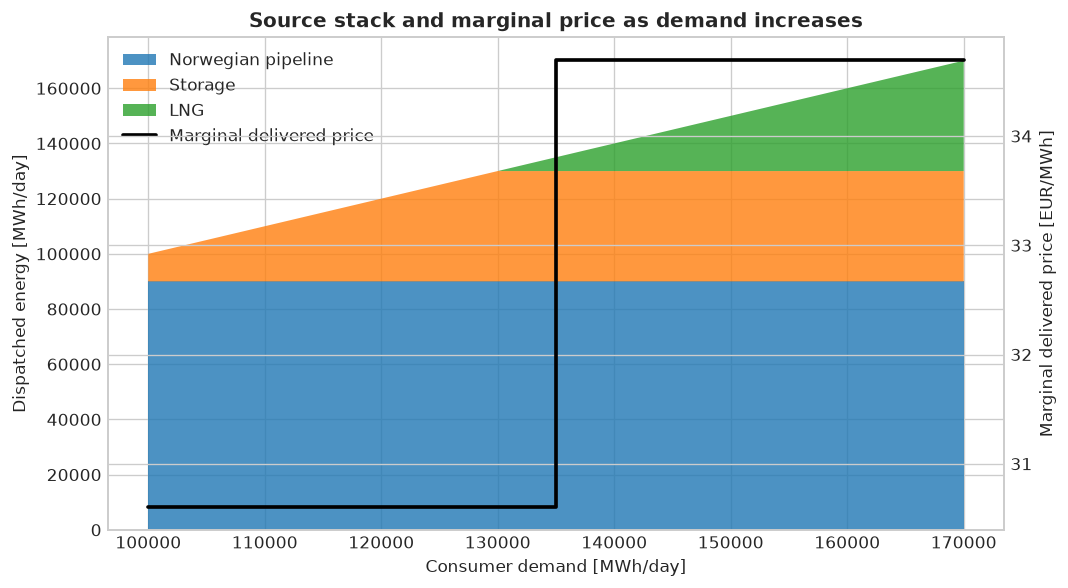

In [12]:
dispatch_rows = []
for demand_mwh in np.arange(100_000.0, 170_001.0, 10_000.0):
    result = solve_dispatch(demand_mwh)
    dispatch_rows.append(
        {
            "Demand [MWh/day]": demand_mwh,
            "Norwegian pipeline": result.x[0],
            "Storage withdrawal": result.x[1],
            "LNG": result.x[2],
            "Marginal price [EUR/MWh]": result.eqlin.marginals[0],
        }
    )

demand_sensitivity = pd.DataFrame(dispatch_rows)
figure, left_axis = plt.subplots(figsize=(9, 5))
left_axis.stackplot(
    demand_sensitivity["Demand [MWh/day]"],
    demand_sensitivity["Norwegian pipeline"],
    demand_sensitivity["Storage withdrawal"],
    demand_sensitivity["LNG"],
    labels=["Norwegian pipeline", "Storage", "LNG"],
    alpha=0.8,
)
left_axis.set_xlabel("Consumer demand [MWh/day]")
left_axis.set_ylabel("Dispatched energy [MWh/day]")
right_axis = left_axis.twinx()
right_axis.step(
    demand_sensitivity["Demand [MWh/day]"],
    demand_sensitivity["Marginal price [EUR/MWh]"],
    color="black",
    where="mid",
    linewidth=2.2,
    label="Marginal delivered price",
)
right_axis.set_ylabel("Marginal delivered price [EUR/MWh]")
left_axis.set_title("Source stack and marginal price as demand increases")
handles_left, labels_left = left_axis.get_legend_handles_labels()
handles_right, labels_right = right_axis.get_legend_handles_labels()
left_axis.legend(handles_left + handles_right, labels_left + labels_right)
figure.tight_layout()
plt.show()

## 6. Consumer perspective: delivered cost and price risk

An industrial consumer contracts with a supplier or trades directly if qualified. It cares
about delivered energy, reliability, flexibility, credit, profile tolerance, taxes, and
price-risk policy. A supplier can quote fixed price, hub-index plus fee, or a structured
hedge. Network and tax components depend on location and consumer class.

Illustrative delivered cost: 37.15 EUR/MWh
Illustrative daily bill: 5.573 million EUR
Taxes, levies, VAT, and carbon pass-through are excluded.


,Component,EUR/MWh
0,TTF-indexed commodity,34.00
1,Hub basis and local transmission,0.70
2,Supplier service and credit,0.45
3,Expected balancing allowance,0.20
4,Distribution and metering,1.80


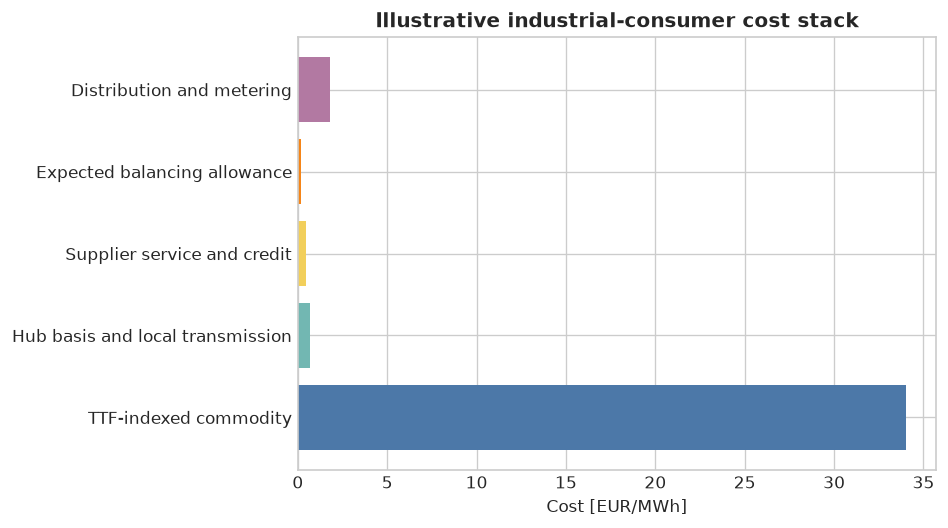

In [13]:
delivered_wholesale_price = float(base_dispatch.eqlin.marginals[0])
last_mile_transport_eur_mwh = 0.70
ttf_reference_price = delivered_wholesale_price - last_mile_transport_eur_mwh
consumer_components = pd.DataFrame(
    {
        "Component": [
            "TTF-indexed commodity",
            "Hub basis and local transmission",
            "Supplier service and credit",
            "Expected balancing allowance",
            "Distribution and metering",
        ],
        "EUR/MWh": [
            ttf_reference_price,
            last_mile_transport_eur_mwh,
            0.45,
            0.20,
            1.80,
        ],
    }
)
consumer_unit_cost = consumer_components["EUR/MWh"].sum()
consumer_daily_bill = consumer_unit_cost * DAILY_DEMAND_MWH
display(consumer_components.round(2))
print(f"Illustrative delivered cost: {consumer_unit_cost:.2f} EUR/MWh")
print(f"Illustrative daily bill: {consumer_daily_bill / 1.0e6:.3f} million EUR")
print("Taxes, levies, VAT, and carbon pass-through are excluded.")

figure, axis = plt.subplots(figsize=(8, 4.5))
axis.barh(
    consumer_components["Component"],
    consumer_components["EUR/MWh"],
    color=["#4C78A8", "#72B7B2", "#F2CF5B", "#F58518", "#B279A2"],
)
axis.set_xlabel("Cost [EUR/MWh]")
axis.set_title("Illustrative industrial-consumer cost stack")
figure.tight_layout()
plt.show()

,Mean [EUR/MWh],Std. dev. [EUR/MWh],95th percentile [EUR/MWh]
Spot plus service,33.71,5.01,40.92
Fixed,36.50,0.00,36.50
50% fixed / 50% indexed,35.10,2.50,38.71


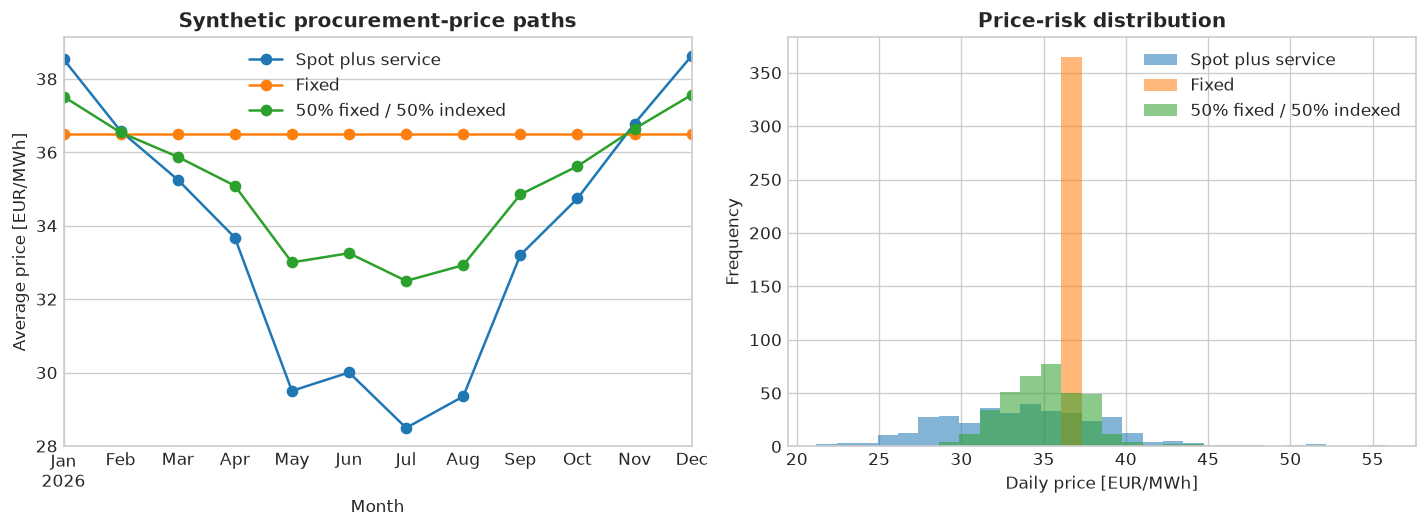

In [14]:
rng = np.random.default_rng(20260805)
day_index = pd.date_range("2026-01-01", periods=365, freq="D")
season = 33.0 + 5.0 * np.cos(2.0 * np.pi * np.arange(365) / 365.0)
spot_price = season + rng.normal(0.0, 2.8, size=365)
spike_days = rng.choice(np.arange(365), size=8, replace=False)
spot_price[spike_days] += rng.uniform(8.0, 18.0, size=len(spike_days))
spot_price = np.clip(spot_price, 18.0, None)

fixed_price = np.full(365, 36.5)
indexed_price = spot_price + 0.45
half_hedged_price = 0.5 * fixed_price + 0.5 * indexed_price
price_strategies = pd.DataFrame(
    {
        "Spot plus service": indexed_price,
        "Fixed": fixed_price,
        "50% fixed / 50% indexed": half_hedged_price,
    },
    index=day_index,
)
risk_table = pd.DataFrame(
    {
        "Mean [EUR/MWh]": price_strategies.mean(),
        "Std. dev. [EUR/MWh]": price_strategies.std(),
        "95th percentile [EUR/MWh]": price_strategies.quantile(0.95),
    }
)
display(risk_table.round(2))

monthly_prices = price_strategies.resample("MS").mean()
figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
monthly_prices.plot(ax=axes[0], marker="o")
axes[0].set_ylabel("Average price [EUR/MWh]")
axes[0].set_xlabel("Month")
axes[0].set_title("Synthetic procurement-price paths")
price_strategies.plot.hist(ax=axes[1], bins=28, alpha=0.55)
axes[1].set_xlabel("Daily price [EUR/MWh]")
axes[1].set_title("Price-risk distribution")
figure.tight_layout()
plt.show()

## 7. Shipper and transporter: capacity, nomination, and balance

The shipper holds transport rights, nominates, and is financially responsible for its
imbalance. The TSO validates nominations, operates safely, meters and allocates flow,
procures balancing actions, and invoices tariffs. Its regulated transport revenue is not
a commodity-trading spread.

,Schedule,Net short volume [MWh],Gross imbalance charge [EUR]
0,Day-ahead only,4000.0,172627.1
1,Renominated at hour 12,1335.8,80534.8


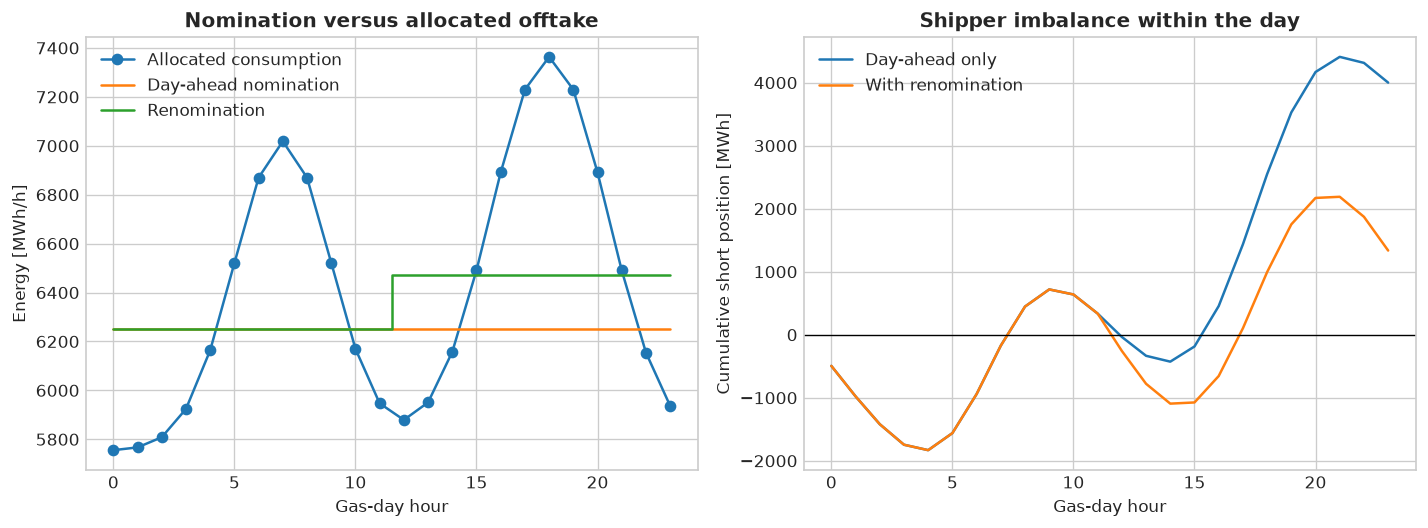

In [15]:
hours = np.arange(24)
shape = (
    1.0
    + 0.22 * np.exp(-0.5 * ((hours - 7.0) / 2.0) ** 2)
    + 0.28 * np.exp(-0.5 * ((hours - 18.0) / 2.4) ** 2)
)
actual_total_mwh = 154_000.0
actual_hourly_mwh = actual_total_mwh * shape / shape.sum()
day_ahead_nomination_mwh = np.full(24, DAILY_DEMAND_MWH / 24.0)
renominated_mwh = day_ahead_nomination_mwh.copy()
renominated_mwh[12:] = (actual_hourly_mwh[12:].sum() - 1_000.0) / 12.0


def imbalance_settlement(schedule_mwh, actual_mwh, reference_price):
    imbalance = actual_mwh - schedule_mwh
    short_cost = np.maximum(imbalance, 0.0) * reference_price * 1.10
    surplus_credit = -np.minimum(imbalance, 0.0) * reference_price * 0.90
    return imbalance, short_cost - surplus_credit


day_ahead_imbalance, day_ahead_cost = imbalance_settlement(
    day_ahead_nomination_mwh,
    actual_hourly_mwh,
    ttf_reference_price,
)
renom_imbalance, renom_cost = imbalance_settlement(
    renominated_mwh,
    actual_hourly_mwh,
    ttf_reference_price,
)
imbalance_summary = pd.DataFrame(
    {
        "Schedule": ["Day-ahead only", "Renominated at hour 12"],
        "Net short volume [MWh]": [
            day_ahead_imbalance.sum(),
            renom_imbalance.sum(),
        ],
        "Gross imbalance charge [EUR]": [
            day_ahead_cost.sum(),
            renom_cost.sum(),
        ],
    }
)
display(imbalance_summary.round(1))

figure, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].plot(hours, actual_hourly_mwh, marker="o", label="Allocated consumption")
axes[0].step(
    hours,
    day_ahead_nomination_mwh,
    where="mid",
    label="Day-ahead nomination",
)
axes[0].step(hours, renominated_mwh, where="mid", label="Renomination")
axes[0].set_xlabel("Gas-day hour")
axes[0].set_ylabel("Energy [MWh/h]")
axes[0].set_title("Nomination versus allocated offtake")
axes[0].legend()
axes[1].plot(hours, np.cumsum(day_ahead_imbalance), label="Day-ahead only")
axes[1].plot(hours, np.cumsum(renom_imbalance), label="With renomination")
axes[1].axhline(0.0, color="black", linewidth=0.8)
axes[1].set_xlabel("Gas-day hour")
axes[1].set_ylabel("Cumulative short position [MWh]")
axes[1].set_title("Shipper imbalance within the day")
axes[1].legend()
figure.tight_layout()
plt.show()

In [16]:
BOOKED_CAPACITY_MWH_H = 8_500.0
CAPACITY_TARIFF_EUR_MWH_BOOKED = 0.10
VOLUMETRIC_TARIFF_EUR_MWH_ALLOCATED = 0.25
booked_daily_capacity_mwh = BOOKED_CAPACITY_MWH_H * 24.0
capacity_invoice_eur = (
    booked_daily_capacity_mwh * CAPACITY_TARIFF_EUR_MWH_BOOKED
)
volume_invoice_eur = (
    actual_total_mwh * VOLUMETRIC_TARIFF_EUR_MWH_ALLOCATED
)
transport_view = pd.Series(
    {
        "Booked right [MWh/day]": booked_daily_capacity_mwh,
        "Nominated energy [MWh/day]": day_ahead_nomination_mwh.sum(),
        "Allocated energy [MWh/day]": actual_total_mwh,
        "Peak allocation [MWh/h]": actual_hourly_mwh.max(),
        "Booked peak [MWh/h]": BOOKED_CAPACITY_MWH_H,
        "Daily utilisation [%]": (
            100.0 * actual_total_mwh / booked_daily_capacity_mwh
        ),
        "Capacity invoice [EUR/day]": capacity_invoice_eur,
        "Volumetric invoice [EUR/day]": volume_invoice_eur,
        "Commodity trading revenue [EUR/day]": 0.0,
    },
    name="Illustrative transporter ledger",
)
display(transport_view.to_frame().round(2))

,Illustrative transporter ledger
Booked right [MWh/day],204000.00
Nominated energy [MWh/day],150000.00
Allocated energy [MWh/day],154000.00
Peak allocation [MWh/h],7363.57
Booked peak [MWh/h],8500.00
Daily utilisation [%],75.49
Capacity invoice [EUR/day],20400.00
Volumetric invoice [EUR/day],38500.00
Commodity trading revenue [EUR/day],0.00


## 8. Producer perspective: hub realisation and netback

A producer can sell at a field, terminal, landing point, or hub; combine long-term and
spot contracts; and hedge separately. A delivered hub receipt must cover upstream
operating cost, processing, energy, transport, emissions, flexibility, imbalance, and
contract risk. What remains is contribution netback, not accounting profit.

,Illustrative producer view
TTF reference [EUR/MWh],34.000
Field variable cost [EUR/MWh],7.000
Norwegian transport [EUR/MWh],1.600
NeqSim compression electricity [EUR/MWh],0.209
Emissions and loss allowance [EUR/MWh],0.400
Netback contribution [EUR/MWh],24.791
Dispatched Norwegian gas [MWh/day],90000.000
Daily contribution [million EUR],2.231


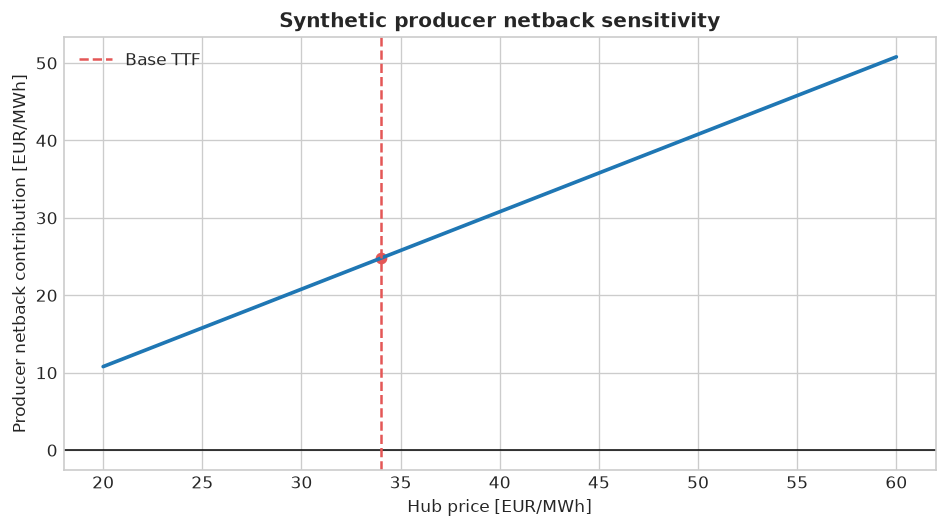

In [17]:
hub_price_grid = np.linspace(20.0, 60.0, 81)
FIELD_VARIABLE_COST_EUR_MWH = 7.0
NORWEGIAN_TRANSPORT_EUR_MWH = 1.60
EMISSIONS_AND_LOSS_EUR_MWH = 0.40
producer_deductions_eur_mwh = (
    FIELD_VARIABLE_COST_EUR_MWH
    + NORWEGIAN_TRANSPORT_EUR_MWH
    + EMISSIONS_AND_LOSS_EUR_MWH
    + compression_cost_eur_mwh
)
netback_grid = hub_price_grid - producer_deductions_eur_mwh
base_netback_eur_mwh = ttf_reference_price - producer_deductions_eur_mwh
norwegian_flow_mwh = float(base_dispatch.x[0])
base_daily_contribution_eur = base_netback_eur_mwh * norwegian_flow_mwh
producer_summary = pd.Series(
    {
        "TTF reference [EUR/MWh]": ttf_reference_price,
        "Field variable cost [EUR/MWh]": FIELD_VARIABLE_COST_EUR_MWH,
        "Norwegian transport [EUR/MWh]": NORWEGIAN_TRANSPORT_EUR_MWH,
        "NeqSim compression electricity [EUR/MWh]": compression_cost_eur_mwh,
        "Emissions and loss allowance [EUR/MWh]": EMISSIONS_AND_LOSS_EUR_MWH,
        "Netback contribution [EUR/MWh]": base_netback_eur_mwh,
        "Dispatched Norwegian gas [MWh/day]": norwegian_flow_mwh,
        "Daily contribution [million EUR]": base_daily_contribution_eur / 1.0e6,
    },
    name="Illustrative producer view",
)
display(producer_summary.to_frame().round(3))

figure, axis = plt.subplots(figsize=(8, 4.5))
axis.plot(hub_price_grid, netback_grid, linewidth=2.2)
axis.axhline(0.0, color="black", linewidth=0.9)
axis.axvline(ttf_reference_price, color="#E45756", linestyle="--", label="Base TTF")
axis.scatter([ttf_reference_price], [base_netback_eur_mwh], color="#E45756")
axis.set_xlabel("Hub price [EUR/MWh]")
axis.set_ylabel("Producer netback contribution [EUR/MWh]")
axis.set_title("Synthetic producer netback sensitivity")
axis.legend()
figure.tight_layout()
plt.show()

## 9. Reconcile the three perspectives

Consumer payment must equal receipts by the producer, transport systems, supplier, and
balancing service in a closed teaching ledger. The producer line is net of Norwegian
transport but before field and compression costs, avoiding double counting upstream
transport in both hub price and consumer add-ons.

In [18]:
downstream_network_receipt = last_mile_transport_eur_mwh + 1.80
producer_receipt_net_transport = (
    ttf_reference_price - NORWEGIAN_TRANSPORT_EUR_MWH
)
cash_ledger = pd.DataFrame(
    {
        "Actor": [
            "Industrial consumer",
            "Producer marketing entity",
            "Norwegian transporter",
            "Supplier and credit service",
            "Balancing service allowance",
            "Downstream networks",
        ],
        "Cash [EUR/MWh]": [
            -consumer_unit_cost,
            producer_receipt_net_transport,
            NORWEGIAN_TRANSPORT_EUR_MWH,
            0.45,
            0.20,
            downstream_network_receipt,
        ],
    }
)
cash_closure_eur_mwh = cash_ledger["Cash [EUR/MWh]"].sum()
display(cash_ledger.round(3))
print(f"External cash-ledger closure: {cash_closure_eur_mwh:.6f} EUR/MWh")

perspective_summary = pd.DataFrame(
    [
        ["Consumer", "contract and hedge demand",
         "price, volume, reliability, credit",
         f"{consumer_unit_cost:.2f} EUR/MWh delivered"],
        ["Shipper / transporter", "book, nominate, balance, operate",
         "imbalance, congestion, utilisation, regulation",
         f"{100.0 * actual_total_mwh / booked_daily_capacity_mwh:.1f}% utilisation"],
        ["Producer", "sell, route, hedge, optimise portfolio",
         "hub price, basis, quality, capacity, cost",
         f"{base_netback_eur_mwh:.2f} EUR/MWh netback"],
    ],
    columns=["Perspective", "Primary decision", "Key exposure", "Base metric"],
)
display(perspective_summary)

External cash-ledger closure: -0.000000 EUR/MWh


,Actor,Cash [EUR/MWh]
0,Industrial consumer,-37.15
1,Producer marketing entity,32.40
2,Norwegian transporter,1.60
3,Supplier and credit service,0.45
4,Balancing service allowance,0.20
5,Downstream networks,2.50


,Perspective,Primary decision,Key exposure,Base metric
0,Consumer,contract and hedge demand,"price, volume, reliability, credit",37.15 EUR/MWh delivered
1,Shipper / transporter,"book, nominate, balance, operate","imbalance, congestion, utilisation, regulation",75.5% utilisation
2,Producer,"sell, route, hedge, optimise portfolio","hub price, basis, quality, capacity, cost",24.79 EUR/MWh netback


## 10. How this connects to the NeqSim-Colab value chain

Use this notebook as the commercial layer between physical production and portfolio
decisions:

1. [Gas processing value chain](GasProcessingChain.ipynb) — physical conditioning,
   compression, dehydration, pipeline transport, and quality.
2. **This notebook** — title, hubs, contracts, capacity, nominations, balance, and cash.
3. [Reservoir-to-market system curves](../reservoir/reservoir_well_topside_market_system_curves.ipynb)
   — production response from reservoir to delivery.
4. [Stochastic reservoir-to-market optimisation](../reservoir/stochastic_reservoir_to_market_optimization.ipynb)
   — internally consistent reservoir, process, market, and economic realisations.
5. [Dry-gas pipeline-network optimisation](../process/PipeNetworkOptim.ipynb) — pressure,
   capacity, compression, and delivery-node mixing.
6. [CO2 emissions across the gas value chain](../emissions/CO2emsissionsinthevaluechain.ipynb)
   — lifecycle boundaries and emissions sensitivity.
7. [Natural gas and the World Energy Outlook](energystatistics.ipynb) — demand and supply
   scenarios around the market mechanics developed here.

## 11. Limitations

- Dispatch costs, basis, tariffs, profiles, and contracts are synthetic. Replace them with
  licensed, dated, versioned data before market use.
- The linear model omits linepack, pressure, compressor maps, storage inventory, ramping,
  losses, bids, spreads, collateral, and unit commitment.
- National balancing rules, gas-day definitions, licences, taxes, and consumer protection
  differ. Review the applicable code and contract.
- TTF is illustrative. Physical delivery and basis risk may be in another balancing zone.
- ISO 6976 is one quality layer. Add water, sulfur, CO2, oxygen, hydrocarbon dew point,
  measurement uncertainty, and every contractual limit.

No NeqSim limitation blocked this work: current SRK, ISO 6976, stream, compressor, and
`ProcessSystem` APIs were sufficient for the demonstrated market-to-physics bridge.

In [19]:
validation_checks = {
    "NeqSim class loaded from source-built JAR": str(NEQSIM_JAR) in class_source,
    "Base composition closes": math.isclose(
        sum(BASE_GAS.values()),
        1.0,
        abs_tol=1.0e-12,
    ),
    "CO2-rich composition closes": math.isclose(
        sum(CO2_RICH_GAS.values()),
        1.0,
        abs_tol=1.0e-12,
    ),
    "Gross CV is physically plausible": (
        35.0 < base_quality["Gross CV [MJ/Sm3]"] < 45.0
    ),
    "CO2 lowers gross CV": (
        rich_quality["Gross CV [MJ/Sm3]"]
        < base_quality["Gross CV [MJ/Sm3]"]
    ),
    "Equal energy needs more CO2-rich volume": rich_volume_msm3 > base_volume_msm3,
    "Compression pressure increases": (
        export_compressor.getOutletStream().getPressure("bara")
        > export_feed.getPressure("bara")
    ),
    "Compression power is positive": compressor_power_mw > 0.0,
    "Dispatch closes demand": math.isclose(
        base_dispatch.x.sum(),
        DAILY_DEMAND_MWH,
        abs_tol=1.0e-6,
    ),
    "Dispatch respects source capacity": bool(
        np.all(base_dispatch.x <= routes["Capacity [MWh/day]"] + 1.0e-8)
    ),
    "Allocation respects booked peak": (
        actual_hourly_mwh.max() <= BOOKED_CAPACITY_MWH_H
    ),
    "External cash ledger closes": abs(cash_closure_eur_mwh) < 1.0e-10,
}
validation_table = pd.DataFrame(
    {"Check": list(validation_checks), "Passed": list(validation_checks.values())}
)
display(validation_table)
assert all(validation_checks.values())
print(f"All {len(validation_checks)} named validation checks passed.")

All 12 named validation checks passed.


,Check,Passed
0,NeqSim class loaded from source-built JAR,True
1,Base composition closes,True
2,CO2-rich composition closes,True
3,Gross CV is physically plausible,True
4,CO2 lowers gross CV,True
5,Equal energy needs more CO2-rich volume,True
6,Compression pressure increases,True
7,Compression power is positive,True
8,Dispatch closes demand,True
9,Dispatch respects source capacity,True


In [20]:
provenance = pd.DataFrame(
    {
        "Component": [
            "NeqSim Java",
            "NeqSim JAR SHA-256",
            "Java class source",
            "Python",
            "JPype",
            "NumPy",
            "pandas",
            "SciPy",
            "NetworkX",
            "Market-case data",
        ],
        "Version or identity": [
            NEQSIM_COMMIT,
            NEQSIM_JAR_SHA256,
            class_source,
            platform.python_version(),
            metadata.version("jpype1"),
            np.__version__,
            pd.__version__,
            scipy.__version__,
            nx.__version__,
            "synthetic teaching snapshot dated 2026-08-05",
        ],
    }
)
display(provenance)
result_summary = {
    "gross_cv_mj_sm3": base_quality["Gross CV [MJ/Sm3]"],
    "compression_power_mw": compressor_power_mw,
    "dispatch_marginal_price_eur_mwh": float(
        base_dispatch.eqlin.marginals[0]
    ),
    "consumer_delivered_cost_eur_mwh": consumer_unit_cost,
    "producer_netback_eur_mwh": base_netback_eur_mwh,
    "named_checks_passed": int(sum(validation_checks.values())),
}
print(json.dumps(result_summary, indent=2))

{
  "gross_cv_mj_sm3": 39.551652386668074,
  "compression_power_mw": 13.696341725656794,
  "dispatch_marginal_price_eur_mwh": 34.7,
  "consumer_delivered_cost_eur_mwh": 37.150000000000006,
  "producer_netback_eur_mwh": 24.79056380768381,
  "named_checks_passed": 12
}


,Component,Version or identity
0,NeqSim Java,7ae08253b45180045a99a700314f23c9a7001b3c
1,NeqSim JAR SHA-256,03c88c492eca2c989aed2a8495248d68f85e29c260609d...
2,Java class source,file:/workspace/scratch/677f236dc7cc/gas-marke...
3,Python,3.12.13
4,JPype,1.7.1
5,NumPy,2.5.1
6,pandas,3.0.5
7,SciPy,1.18.0
8,NetworkX,3.6.1
9,Market-case data,synthetic teaching snapshot dated 2026-08-05


## Suggested exercises

1. Snapshot ENTSOG point flows and map Norwegian entries to hubs.
2. Add AGSI inventory and optimise storage over one gas year.
3. Replace demand with Eurostat country and sector profiles.
4. Model fixed, indexed, collar, and swing contracts with volume optionality.
5. Add TTF–THE basis, spreads, collateral, and cash-flow-at-risk.
6. Replace route costs with NeqSim pressure, compression, loss, and quality maps.
7. Join market scenario keys to the stochastic reservoir-to-market notebook without
   independently mixing technical and commercial percentiles.

## Primary references and API documentation

- [European Commission gas network codes](https://energy.ec.europa.eu/topics/markets-and-consumers/wholesale-energy-market/gas-network-codes_en)
- [ENTSOG Transparency Platform API manual](https://transparency.entsog.eu/api/archiveDirectories/8/api-manual/ENTSOG_TP_API_UserManual_v3.0.pdf)
- [GIE AGSI/ALSI API documentation](https://www.gie.eu/transparency-platform/GIE_API_documentation_v007.pdf)
- [Eurostat Statistics API guide](https://ec.europa.eu/eurostat/web/user-guides/data-browser/api-data-access/api-getting-started/api)
- [Eurostat industrial gas prices](https://ec.europa.eu/eurostat/databrowser/product/view/nrg_pc_203)
- [Gassco capacity booking](https://gassco.eu/en/shippers/capacity-booking-and-reporting/)
- [ACER gas market monitoring](https://www.acer.europa.eu/monitoring/MMR)
- [JRC `eurogastp`](https://github.com/ec-jrc/eurogastp)
- [Community `entsog-py`](https://github.com/nhcb/entsog-py)

The evidence level is analytical balance and thermodynamic consistency: composition,
ISO 6976 trend, pressure ordering, dispatch energy balance, capacity bounds, and cash
closure. Synthetic prices are not calibrated to an observed gas day.